# Housing Unit Allocation with Person Record File Full Workflow

## Overview
This code works with the National Structures Inventory to run the housing unit allocation (HUA) and the person record file (PREC) workflow.
The HUA process is generalizable to any county in the United States. The HUA process will work for any file that has locations of structures and some basic information about the buildings.
The process is designed to work with [IN-CORE](https://incore.ncsa.illinois.edu/), a community resilience modeling environment.
Using IN-CORE requires an account and access to the IN-CORE Dataservice.

Functions are provided to obtain and clean data required for the version 2 Housing Unit Allocation. 

## Required Inputs
Program requires the following inputs:
If using the National Structures Inventory there are no required inputs.
    
## Output Description
The output of this workflow is a CSV file with the housing unit inventory allocated to a building inventory using the housing unit allocation model.

The output CSV is designed to be used in the Interdependent Networked Community Resilience Modeling Environment (IN-CORE).

IN-CORE is an open source python package that can be used to model the resilience of a community. To download IN-CORE, see:

https://incore.ncsa.illinois.edu/


## Instructions
Users can run the workflow by executing each block of code in the notebook.

## Description of Program
- program:    ncoda_07jv3_HUA_NSI_Hayward
- task:       Start with NSI building inventory, run housing unit allocation algorithm, and then run person record file algorithm
- See github commits for description of program updates
- Current Version: v3 - 
- 2024-02-20 - Combine code from 07c, 07d, and 07e into one notebook
- 2024-05-22 - removed the drop down menu, did not work consistently
- 2025-02-21 - Test with 2020 HUI
- 2025-03-07 - Update to version 2 to differentiate running 2010 and 2020
- 2025-03-27 - V3 Solved issue for states starting with 0 FIPS code - major modification to code
- 2025-09-17 - Adjust code to run a Monte Carlo Simulation
- 2026-04-16 - Running code to explore missing building data
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [1]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

### How to set up the Community Dictionary
Please review the python code in the file pyncoda/ncoda_00g_community_options.py

In this file you will find a collection of data dictionaries with various ways to setup the inputs for the Housing Unit Allocation process. 

The basic dictionary includes the name of the community, the county FIPS code, your input building inventory file, and key variables in the building inventory file.

In [2]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos Coun

In [3]:
community_id_by_name = 'Hayward, CA: NSI Building inventory for Alameda County, CA, 2010'

In [4]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Hayward_CA_NSI
Hayward, CA is in CALIFORNIA
Focal place: Hayward
Hayward, CA is in Alameda County, CA with FIPS code 06001
Use IN-CORE: False


## Setup Python Environment

In [5]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [6]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [7]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Thu Apr 16 16:36:38 2026 Central Daylight Time

                OS : Windows (10 10.0.26200 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [8]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

## Run Housing Unit Allocation
The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Inventory
3. Housing Unit Allocation

In [9]:
basevintage_options = ['2010']

In [10]:
hua_hui_gdf_dict = {}
base_seed = 9876
iterations = 1
# iterate through basevintage options to run Monte Carlo Simulation
for basevintage in basevintage_options:
    hua_hui_gdf_dict[basevintage] = {}
    for i in range(iterations):
        seed_i = base_seed + i
        print(f"Running iteration {i+1} of {iterations} for basevintage {basevintage} with seed {seed_i}")
        workflow = process_community_workflow(
                    communities,
                    seed = seed_i,
                    version = '2.1.0',
                    version_text = 'v2-1-0',
                    basevintage = basevintage,
                    outputfolder ="OutputData",
                    outputfolders = {},
                    savefiles = True)
        hua_hui_gdf_dict[basevintage][seed_i] = workflow.process_communities()

Running iteration 1 of 1 for basevintage 2010 with seed 9876
Generating Housing Unit Inventory v2.0.0 data for Hayward, CA
Alameda County, CA : county FIPS Code 06001
File already exists, skipping: OutputData/Hayward_CA_NSI/../hui_v2-1-0_Hayward_CA_NSI_2010_rs9876.csv
Checking output for huid
Checking output for blockid
Checking output for bgid
Checking output for tractid
Checking output for FIPScounty
Checking output for numprec
Checking output for ownershp
Checking output for race
Checking output for hispan
Checking output for family
Checking output for vacancy
Checking output for gqtype
Checking output for incomegroup
Checking output for hhinc
Checking output for randincome
Checking output for poverty
Checking huid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
Checking blockid Data Type
   Current type: <class 'pandas.core.series.Series'> Expected type <class 'str'>
    Attempt to fix length of blockid
Checking bgid Data Type
   Current t

## Explore and Validate Housing Unit Allocation


### Look at population characteristics and compare to US Census

In [12]:
focalplace = communities[community_id]['community_name']
print(focalplace, focalplace, countyname, countyfips)

Hayward, CA Hayward, CA Alameda County, CA 06001


In [13]:
hua_gdf = hua_hui_gdf_dict['2010'][9876]

In [14]:
PopResultsTable.pop_results_table(
                  input_df = hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","354,848 (43.4%)","176,870 (27.8%)","531,718 (36.5%)"
"2 Black alone, Not Hispanic","59,667 (7.3%)","111,333 (17.5%)","171,000 (11.8%)"
"3 American Indian and Alaska Native alone, Not Hispanic","1,468 (0.2%)","2,057 (0.3%)","3,525 (0.2%)"
"4 Asian alone, Not Hispanic","240,249 (29.4%)","134,042 (21.0%)","374,291 (25.7%)"
"5 Other Race, Not Hispanic","23,368 (2.9%)","25,320 (4.0%)","48,688 (3.3%)"
"6 Any Race, Hispanic","138,722 (17.0%)","187,253 (29.4%)","325,975 (22.4%)"
Total,"818,322 (100.0%)","636,875 (100.0%)","1,455,197 (100.0%)"


In [15]:
PopResultsTable.pop_results_table(hua_gdf, 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$96,313","$69,092","$85,396"
"2 Black alone, Not Hispanic","$51,097","$39,144","$43,041"
"3 American Indian and Alaska Native alone, Not Hispanic","$66,294","$46,984","$53,527"
"4 Asian alone, Not Hispanic","$104,274","$66,249","$88,095"
"5 Other Race, Not Hispanic","$76,302","$57,312","$64,782"
"6 Any Race, Hispanic","$64,425","$51,340","$56,632"
Total,"$88,275","$56,883","$71,405"


In [16]:
hua_gdf.head()

,huid,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,family,...,incomegroup,hhinc,randincome,poverty,fd_id_bid,placeNAME10,huestimate,x,y,geometry
0,B060014001001007H0001,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,13.0,5.0,122331.0,0.0,nsi-474648750-849VVQ65+J2C-2-2-3-3,Oakland,2.0,-122.242497,37.861551,POINT (-122.24 37.862)
1,B060014001001007H0002,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,16.0,5.0,249702.0,0.0,nsi-474648764-849VVQ65+PW4-1-3-2-2,Oakland,2.0,-122.240157,37.861752,POINT (-122.24 37.862)
2,B060014001001007H0003,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,12.0,4.0,81115.0,0.0,nsi-474648761-849VVQ64+JV4-5-4-3-3,Oakland,2.0,-122.242793,37.861523,POINT (-122.24 37.862)
3,B060014001001007H0004,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,15.0,5.0,185826.0,0.0,nsi-474648762-849VVQ65+MC5-2-3-2-3,Oakland,2.0,-122.241380,37.861648,POINT (-122.24 37.862)
4,B060014001001007H0005,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,15.0,5.0,173579.0,0.0,nsi-474648765-849VVQ64+PQ7-2-2-2-3,Oakland,2.0,-122.243089,37.861795,POINT (-122.24 37.862)


In [17]:
# Show population counts by placeNAME10 - weight by numprec
hua_gdf.groupby('placeNAME10').size()

placeNAME10
Alameda            32372
Albany              7898
Ashland             7769
Berkeley           49583
Castro Valley      23428
Cherryland          4998
Dublin             15800
Emeryville          6649
Fairview            3702
Fremont            74046
Hayward            48347
Livermore          30396
Milpitas              32
Newark             13432
Oakland           169958
Piedmont            3925
Pleasanton         25956
San Leandro        32459
San Lorenzo         7685
Sunol                394
Unincorporated      3322
Union City         21321
dtype: int64

In [18]:
focalplace

'Hayward, CA'

In [19]:
# set dataframe for focal place
focalplace_hua_gdf =  hua_gdf.loc[hua_gdf['placeNAME10'] == 'Hayward'].copy(deep=True)

In [20]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","18,244 (24.9%)","9,813 (15.1%)","28,057 (20.3%)"
"2 Black alone, Not Hispanic","4,535 (6.2%)","10,175 (15.6%)","14,710 (10.6%)"
"3 American Indian and Alaska Native alone, Not Hispanic",173 (0.2%),224 (0.3%),397 (0.3%)
"4 Asian alone, Not Hispanic","20,695 (28.2%)","8,516 (13.1%)","29,211 (21.1%)"
"5 Other Race, Not Hispanic","3,917 (5.3%)","3,459 (5.3%)","7,376 (5.3%)"
"6 Any Race, Hispanic","25,702 (35.1%)","32,916 (50.6%)","58,618 (42.4%)"
Total,"73,266 (100.0%)","65,103 (100.0%)","138,369 (100.0%)"


In [21]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$67,776","$53,986","$62,442"
"2 Black alone, Not Hispanic","$66,180","$51,543","$55,242"
"3 American Indian and Alaska Native alone, Not Hispanic","$71,456","$44,709","$62,751"
"4 Asian alone, Not Hispanic","$92,130","$70,579","$85,200"
"5 Other Race, Not Hispanic","$72,086","$58,260","$65,074"
"6 Any Race, Hispanic","$61,950","$52,269","$56,488"
Total,"$70,232","$55,004","$62,753"


In [22]:
hua_gdf['fd_id_bid'].describe()

count                  583472
unique                 390280
top       missing building id
freq                    26198
Name: fd_id_bid, dtype: object

In [23]:
bldg_uniqueid = 'fd_id_bid'
# add category for missing building id
buildingdata_conditions = {'cat_var' : {'variable_label' : 'Building Data Availability',
                         'notes' : 'Does Housing Unit have building data?'},
              'condition_list' : {
                1 : {'condition': f"(df['{bldg_uniqueid}'] == 'missing building id')", 'value_label': "0 Missing Building Data"},
                2 : {'condition': f"(df['{bldg_uniqueid}'] != 'missing building id')", 'value_label': "1 Building Data Available"}}
            }
hua_gdf = add_label_cat_conditions_df(hua_gdf, conditions = buildingdata_conditions)

0 Missing Building Data had 26198 observations
1 Building Data Available had 557274 observations


In [24]:
PopResultsTable.pop_results_table(hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = "2010",
                  row_index = "Race Ethnicity",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Race Ethnicity,,,,
"1 White alone, Not Hispanic","13,139 (24.6%)","518,579 (36.0%)","531,718 (35.6%)",2.5%
"2 Black alone, Not Hispanic","9,720 (18.2%)","161,280 (11.2%)","171,000 (11.5%)",5.7%
"3 American Indian and Alaska Native alone, Not Hispanic",120 (0.2%),"3,405 (0.2%)","3,525 (0.2%)",3.4%
"4 Asian alone, Not Hispanic","16,411 (30.8%)","357,880 (24.9%)","374,291 (25.1%)",4.4%
"5 Other Race, Not Hispanic","2,084 (3.9%)","46,604 (3.2%)","48,688 (3.3%)",4.3%
"6 Any Race, Hispanic","10,176 (19.1%)","315,799 (21.9%)","325,975 (21.8%)",3.1%
7 Group Quarters no Race Ethnicity Data,"1,715 (3.2%)","35,727 (2.5%)","37,442 (2.5%)",4.6%
Total,"53,365 (100.0%)","1,439,274 (100.0%)","1,492,639 (100.0%)",3.6%


In [25]:
focalplace_hua_gdf = add_label_cat_conditions_df(focalplace_hua_gdf, conditions = buildingdata_conditions)

PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = "2010",
                  row_index = "Race Ethnicity",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

0 Missing Building Data had 1831 observations
1 Building Data Available had 46516 observations


Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Race Ethnicity,,,,
"1 White alone, Not Hispanic",689 (16.1%),"27,368 (20.0%)","28,057 (19.9%)",2.5%
"2 Black alone, Not Hispanic","1,133 (26.4%)","13,577 (9.9%)","14,710 (10.4%)",7.7%
"3 American Indian and Alaska Native alone, Not Hispanic",10 (0.2%),387 (0.3%),397 (0.3%),2.5%
"4 Asian alone, Not Hispanic",616 (14.4%),"28,595 (20.9%)","29,211 (20.7%)",2.1%
"5 Other Race, Not Hispanic",254 (5.9%),"7,122 (5.2%)","7,376 (5.2%)",3.4%
"6 Any Race, Hispanic","1,586 (37.0%)","57,032 (41.7%)","58,618 (41.5%)",2.7%
7 Group Quarters no Race Ethnicity Data,3 (0.1%),"2,721 (2.0%)","2,724 (1.9%)",0.1%
Total,"4,291 (100.0%)","136,802 (100.0%)","141,093 (100.0%)",3.0%


In [26]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Tenure Status",
                  where = focalplace,
                  when = "2010",
                  row_index = "Tenure Status",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Tenure Status,,,,
1 Owner Occupied,211 (4.9%),"73,055 (54.5%)","73,266 (52.9%)",0.3%
2 Renter Occupied,"4,077 (95.1%)","61,026 (45.5%)","65,103 (47.1%)",6.3%
Total,"4,288 (100.0%)","134,081 (100.0%)","138,369 (100.0%)",3.1%


In [31]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Income Groups",
                  where = focalplace,
                  when = "2010",
                  row_index = "Household Income Group",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Household Income Group,,,,
"1 Less than $15,000",467 (10.9%),"10,682 (8.0%)","11,149 (8.1%)",4.2%
"2 $15,000 to $24,999",429 (10.0%),"10,667 (8.0%)","11,096 (8.0%)",3.9%
"3 $25,000 to $74,999","1,996 (46.5%)","56,652 (42.3%)","58,648 (42.4%)",3.4%
"4 $75,000 to $99,999",508 (11.8%),"17,578 (13.1%)","18,086 (13.1%)",2.8%
"5 $100,000 or more",888 (20.7%),"38,502 (28.7%)","39,390 (28.5%)",2.3%
Total,"4,288 (100.0%)","134,081 (100.0%)","138,369 (100.0%)",3.1%


#### Validate the Housing Unit Allocation has worked
Notice that the population count totals for the community
should match (pretty closely) data collected for the 2010 Decennial Census.
This can be confirmed by going to data.census.gov

In [27]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALSF12010.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US06001&tid=DECENNIALSF12010.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US06001&tid=ACSDT5Y2012.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US06001&tid=ACSDT5Y2012.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US06001&tid=ACSDT5Y2012.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US06001&tid=ACSDT5Y2012.B19013I


Differences in the housing unit allocation and the Census count may be due to differences between political boundaries and the building inventory. See Rosenheim et al 2019 for more details.

The housing unit allocation, plus the building results will become the input for the social science models such as the population dislocation model.

## Explore Blocks With Missing Data

In [28]:
focalplace

'Hayward, CA'

In [29]:
hua_hui_race_gdf_dict = {}
county_hua_gdf_dict = {}
focal_place_hua_gdf_dict = {}


In [39]:
from pyncoda.ncoda_04b_foliummaps import *
# plot png file
from IPython.display import Image

seed_i = 9876
focalplace = 'Hayward'

In [35]:
# select observations with missing building data for focal place
condition = focalplace_hua_gdf['Building Data Availability_str'] == '0 Missing Building Data'
missing_building_data_gdf = focalplace_hua_gdf[condition]
missing_building_data_gdf.head(1)

,huid,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,family,...,randincome,poverty,fd_id_bid,placeNAME10,huestimate,x,y,geometry,Building Data Availability_int,Building Data Availability_str
43535,B060014312002035H0010,060014312002035,060014312002,06001431200,06001,1,2.0,1.0,0.0,0.0,...,49567.0,0.0,missing building id,Hayward,NaN,-122.080828,37.679898,POINT (-122.08 37.68),1.0,0 Missing Building Data


In [37]:
missing_building_data_gdf[['huid','blockid','bgid','tractid']].describe()

,huid,blockid,bgid,tractid
count,1831,1831,1831,1831
unique,1831,31,22,17
top,B060014312002035H0010,060014312002035,060014312002,06001431200
freq,1,325,346,346


In [43]:
# Show hu counts by blockid
missing_building_block = missing_building_data_gdf.groupby('blockid').size()
# sort by counts
missing_building_block_sorted = missing_building_block.sort_values(ascending=False)
missing_building_block_sorted

blockid
060014312002035    325
060014373002012    203
060014377012001    201
060014378001008    195
060014355002009    145
060014379001016     87
060014363002001     75
060014365001003     71
060014377013001     60
060014381005004     57
060014354003005     54
060014379001017     51
060014363002003     48
060014367001005     47
060014372001008     44
060014364014011     39
060014365001013     23
060014312002037     21
060014351022008     19
060014354003012     16
060014367002024     14
060014373003014     10
060014376001012      9
060014351041027      9
060014355002012      2
060014354001037      1
060014354001017      1
060014373003005      1
060014353002004      1
060014351042015      1
060014355002014      1
dtype: int64

In [46]:
from pyncoda.ncoda_00e_geoutilities import df2gdf_WKTgeometry

tabblock_df = pd.read_csv("OutputData\\tl_2010_Hayward_CA_NSI_tabblockplacepuma10EPSG4269.csv")
tabblock_gdf = df2gdf_WKTgeometry(
    tabblock_df,
    projection="epsg:4269",
    reproject="epsg:4326",
    geometryvar="geometry"
)

# create a blockid based on BLOCKID10_str minus B
tabblock_gdf['blockid'] = tabblock_gdf['BLOCKID10_str'].str.replace('B', '')
# move blockid to the front of the dataframe
cols = tabblock_gdf.columns.tolist()
cols.insert(0, cols.pop(cols.index('blockid')))
tabblock_gdf = tabblock_gdf[cols]
tabblock_gdf.head(1)

Converting geometry to Geodataframe


,blockid,BLOCKID10,BLOCKID10_str,STATEFP10,COUNTYFP10,TRACTCE10,BLOCKCE10,GEOID10,NAME10,MTFCC10,...,INTPTLAT10,INTPTLON10,geometry,rppnt104269,blk104269,placeGEOID10,placeNAME10,placeNAMELSAD10,pumaGEOID10,pumaNAMELSAD10
0,060014507013017,60014507013017,B060014507013017,6,1,450701,3017,60014507013017,Block 3017,G5040,...,37.612156,-121.849736,"POLYGON ((-121.88 37.624, -121.87 37.624, -121...",POINT (-121.8506567890728 37.6084085),"POLYGON ((-121.879919 37.62353299999999, -121....",677042.0,Sunol,Sunol CDP,600110,"Alameda County (East)--Livermore, Pleasanton &..."


<Axes: title={'center': 'Top Block Missing Building Data: 060014312002035'}>

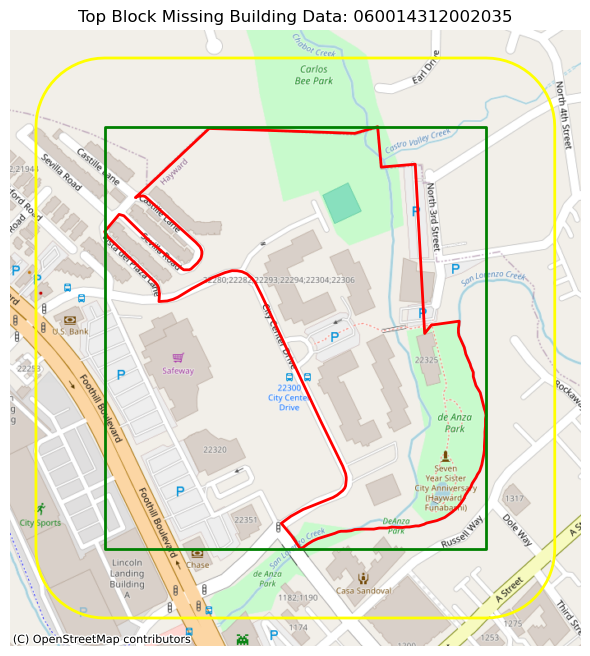

# Look at HUI for Top Block

In [64]:
# set dataframe for focal place
block_hua_gdf =  hua_gdf.loc[hua_gdf['blockid'] == top_block_id].copy(deep=True)

In [68]:
block_hua_gdf.groupby('Building Data Availability_str').size()

Building Data Availability_str
0 Missing Building Data      325
1 Building Data Available     21
dtype: int64

In [65]:
PopResultsTable.pop_results_table(block_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = top_block_id,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic",19 (38.0%),164 (28.6%),183 (29.4%)
"2 Black alone, Not Hispanic",9 (18.0%),153 (26.7%),162 (26.0%)
"4 Asian alone, Not Hispanic",13 (26.0%),74 (12.9%),87 (14.0%)
"5 Other Race, Not Hispanic",4 (8.0%),20 (3.5%),24 (3.9%)
"6 Any Race, Hispanic",5 (10.0%),162 (28.3%),167 (26.8%)
Total,50 (100.0%),573 (100.0%),623 (100.0%)


In [70]:
# add block_hua_gdf to the plot of the top block with missing building data
block_hua_gdf_3857 = block_hua_gdf.to_crs(epsg=3857)

<Axes: title={'center': 'Top Block HUA Points by Building Data Availability: 060014312002035'}>

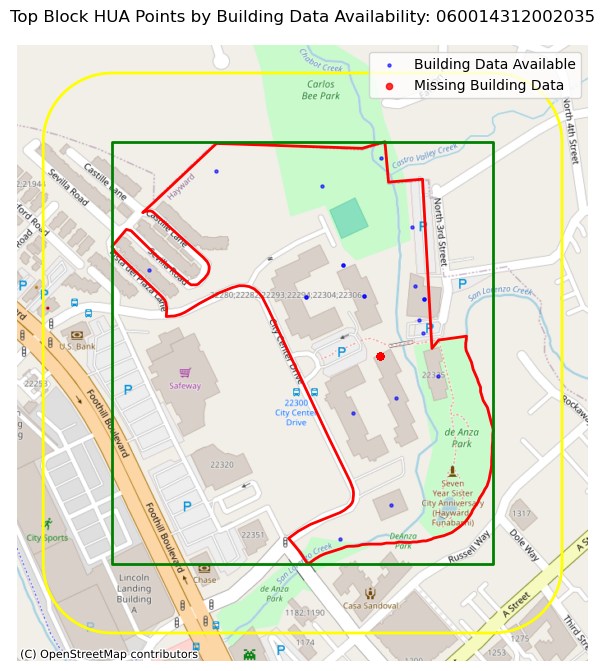

In [72]:
# plot the top 5 blocks with missing building data
import shapely


top5_blocks = missing_building_block_sorted.head(5).index.tolist()
top5_blocks_gdf = tabblock_gdf[tabblock_gdf['blockid'].isin(top5_blocks)].copy(deep=True)

# select the top block from the list
top_block_id = top5_blocks[0]
top_block_gdf = top5_blocks_gdf[top5_blocks_gdf['blockid'] == top_block_id].copy(deep=True)

# using the block boundaries make a rectangle polygon around the block to use as a spatial filter
top_block_bounds = top_block_gdf.total_bounds
top_block_bounds_gdf = gpd.GeoDataFrame([1], geometry=[shapely.geometry.box(*top_block_bounds)], crs=top_block_gdf.crs)

# Reproject bounds to EPSG:3857 for metric buffering
top_block_bounds_gdf_3857 = top_block_bounds_gdf.to_crs(epsg=3857)
top_block_bounds_buffer_gdf_3857 = gpd.GeoDataFrame(
    geometry=top_block_bounds_gdf_3857.buffer(100), crs='epsg:3857'
)

# plot top block with basic OSM background via contextily
top_block_gdf_3857 = top_block_gdf.to_crs(epsg=3857)
ax = top_block_gdf_3857.plot(
    figsize=(8, 8),
    facecolor='none',
    edgecolor='red',
    linewidth=2
)
# add bounding box to the same plot
top_block_bounds_gdf_3857.plot(
    ax=ax,
    facecolor='none',
    edgecolor='green',
    linewidth=2
)
# add 100m buffer to the same plot
top_block_bounds_buffer_gdf_3857.plot(
    ax=ax,
    facecolor='none',
    edgecolor='yellow',
    linewidth=2
)

# overlay block HUA points color-coded by Building Data Availability
block_hua_gdf_3857 = block_hua_gdf.to_crs(epsg=3857)
missing_mask = block_hua_gdf_3857['Building Data Availability_str'] == '0 Missing Building Data'

block_hua_gdf_3857[~missing_mask].plot(
    ax=ax,
    color='blue',
    markersize=5,
    alpha=0.6,
    label='Building Data Available'
)
block_hua_gdf_3857[missing_mask].plot(
    ax=ax,
    color='red',
    markersize=20,
    alpha=0.8,
    label='Missing Building Data'
)
ax.legend()
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title(f"Top Block HUA Points by Building Data Availability: {top_block_id}")
ax.set_axis_off()
ax


### Read in saved NSI data

In [54]:
nsi_gdf = gpd.read_file(r"OutputData\00_SourceData\nsi_sec_usace_army_mil\nsi_01av1_hua_06001.shp") 
nsi_gdf.head(1)

,fd_id_bid,fd_id,bid,occtype,sqft,bldgsource,geometry
0,nsi-473532125-849VJR8V+RVQ-2-2-1-3,473532125,849VJR8V+RVQ-2-2-1-3,COM4,7090.90909,NSI_2026-04-16,POINT (-122.16 37.617)


In [77]:
# select NSI points near the top block 
nsi_gdf_3857 = nsi_gdf.to_crs(epsg=3857)
nsi_near_block_gdf_3857 = nsi_gdf_3857[nsi_gdf_3857.geometry.within(top_block_bounds_buffer_gdf_3857.unary_union)]
nsi_near_block_gdf_3857[['fd_id_bid','occtype']].describe()


C:\Users\nathanael99\AppData\Local\Temp\ipykernel_5232\63169245.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  nsi_near_block_gdf_3857 = nsi_gdf_3857[nsi_gdf_3857.geometry.within(top_block_bounds_buffer_gdf_3857.unary_union)]


,fd_id_bid,occtype
count,145,145
unique,145,24
top,nsi-473598627-849VMWJ8+C49-4-4-3-3,GOV1
freq,1,30


In [78]:
# Group by occtype
nsi_near_block_gdf_3857.groupby('occtype').size()

occtype
COM1          7
COM2          4
COM3          4
COM4         11
COM5          3
COM7          4
COM8          3
EDU1          1
GOV1         30
IND6          4
REL1          1
RES1-1SNB    26
RES1-1SWB     4
RES1-2SNB     2
RES1-2SWB     2
RES1-3SNB     1
RES3A        22
RES3B         1
RES3C         2
RES3D         2
RES3E         4
RES3F         5
RES5          1
RES6          1
dtype: int64

C:\Users\nathanael99\AppData\Local\Temp\ipykernel_5232\2915787756.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  top_block_polygon = top_block_gdf_3857.unary_union


<Axes: title={'center': 'NSI Points Near Top Block by Occupancy Type: 060014312002035'}>

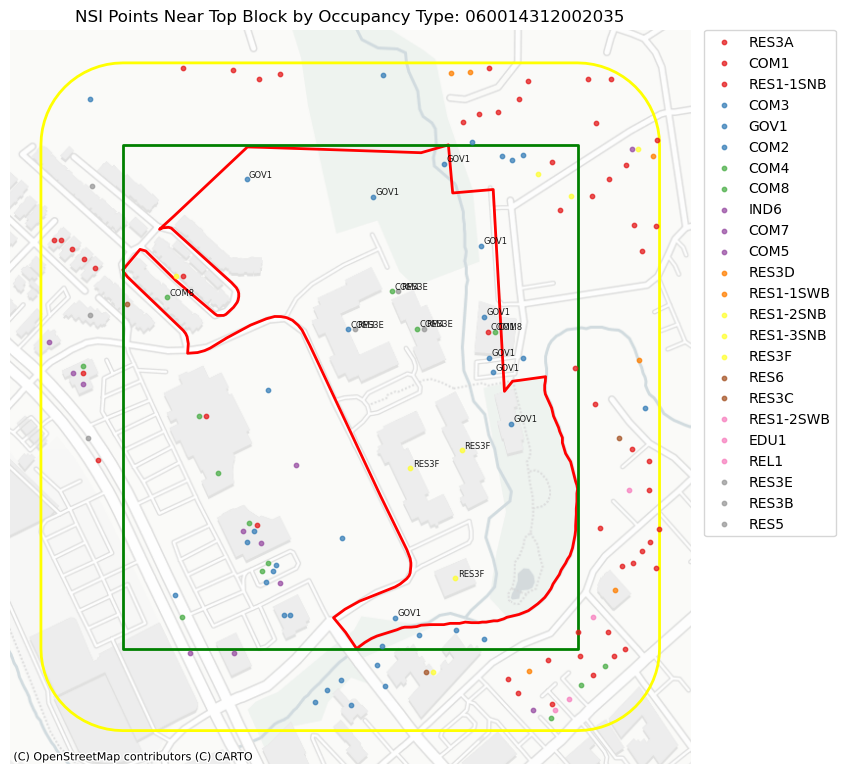

In [87]:
# plot top block with basic OSM background via contextily
top_block_gdf_3857 = top_block_gdf.to_crs(epsg=3857)
ax = top_block_gdf_3857.plot(
    figsize=(10, 8),
    facecolor='none',
    edgecolor='red',
    linewidth=2
)
# add bounding box to the same plot
top_block_bounds_gdf_3857.plot(
    ax=ax,
    facecolor='none',
    edgecolor='green',
    linewidth=2
)
# add 100m buffer to the same plot
top_block_bounds_buffer_gdf_3857.plot(
    ax=ax,
    facecolor='none',
    edgecolor='yellow',
    linewidth=2
)

# build a jittered copy so points at identical coordinates do not overlap
nsi_plot_gdf = nsi_near_block_gdf_3857.copy()
nsi_plot_gdf['x'] = nsi_plot_gdf.geometry.x
nsi_plot_gdf['y'] = nsi_plot_gdf.geometry.y
nsi_plot_gdf['dup_id'] = nsi_plot_gdf.groupby(['x', 'y']).cumcount()
nsi_plot_gdf['dup_n'] = nsi_plot_gdf.groupby(['x', 'y'])['x'].transform('size')

# Increase jitter distance (in meters) so overlapping points are clearly separated
jitter_spacing_m = 8
angle = 2 * np.pi * nsi_plot_gdf['dup_id'] / nsi_plot_gdf['dup_n'].clip(lower=1)
radius = jitter_spacing_m * np.sqrt(nsi_plot_gdf['dup_id'])
nsi_plot_gdf['x_plot'] = nsi_plot_gdf['x'] + radius * np.cos(angle)
nsi_plot_gdf['y_plot'] = nsi_plot_gdf['y'] + radius * np.sin(angle)
nsi_plot_gdf = gpd.GeoDataFrame(
    nsi_plot_gdf,
    geometry=gpd.points_from_xy(nsi_plot_gdf['x_plot'], nsi_plot_gdf['y_plot']),
    crs=nsi_near_block_gdf_3857.crs
)

# label only points whose original geometry falls inside the top block polygon
top_block_polygon = top_block_gdf_3857.unary_union
inside_top_block_idx = nsi_near_block_gdf_3857.index[
    nsi_near_block_gdf_3857.geometry.within(top_block_polygon)
]

# overlay NSI data color-coded by occtype
occtype_categories = nsi_plot_gdf['occtype'].unique()
n = len(occtype_categories)

for i, occtype in enumerate(occtype_categories):
    nsi_group = nsi_plot_gdf[nsi_plot_gdf['occtype'] == occtype]
    category_color = plt.cm.Set1(i / max(n - 1, 1))
    nsi_group.plot(
        ax=ax,
        color=category_color,
        markersize=10,
        alpha=0.75,
        label=occtype
    )

    # labels are restricted to points inside the top block only
    label_group = nsi_group[nsi_group.index.isin(inside_top_block_idx)]
    for _, row in label_group.iterrows():
        ax.text(
            row.geometry.x + 3,
            row.geometry.y + 3,
            str(row['occtype']),
            fontsize=6,
            color='black',
            alpha=0.9
        )

ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)
ax.set_title(f"NSI Points Near Top Block by Occupancy Type: {top_block_id}")
ax.set_axis_off()
plt.tight_layout()
ax
